# Customer & Purchase Behavior


This notebook explores customer purchasing behavior using completed orders to identify patterns related to customer retention, order value, payment behavior, and regional revenue performance.

## Business Questions

1.   How many customers are repeat customers?
2.   How often do customers place multiple orders?
3.   What is the average order value?
4.   Do payment methods and installments influence order value?
5.   Which states have the highest average revenue per customer?
6.   How does average order value change with customer purchase frequency?



## Import Libraries

In [31]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

## Load Data

In [32]:
project_id = "brazilian-e-com-dataset-olist"
client = bigquery.Client(project=project_id)

**Notes:** Only orders with order status 'delivered' are included to measure completed business transactions. Orders with other statuses (e.g. canceled or unavailable) are excluded because they do not represent successfully completed sales.

## How many customers are repeat customers?

In [33]:
query = """
select c.customer_unique_id as customer, count(distinct o.order_id) as total_orders
from `Olist.olist_orders_dataset` o
join `Olist.olist_customers_dataset` c
on o.customer_id = c.customer_id
where order_status = 'delivered'
group by customer
"""
customers = client.query(query).to_dataframe()
customers.head()

,customer,total_orders
0,830d5b7aaa3b6f1e9ad63703bec97d23,1
1,32ea3bdedab835c3aa6cb68ce66565ef,3
2,2f64e403852e6893ae37485d5fcacdaf,1
3,87776adb449c551e74c13fc34f036105,1
4,4e23e1826902ec9f208e8cc61329b494,2


In [34]:
total_customers = len(customers)

repeat_cust = (customers['total_orders'] > 1).sum()

one_time_cust = (customers['total_orders'] == 1).sum()

repeat_percent = (repeat_cust / total_customers * 100).round(2)

one_time_percent = (one_time_cust / total_customers * 100).round(2)


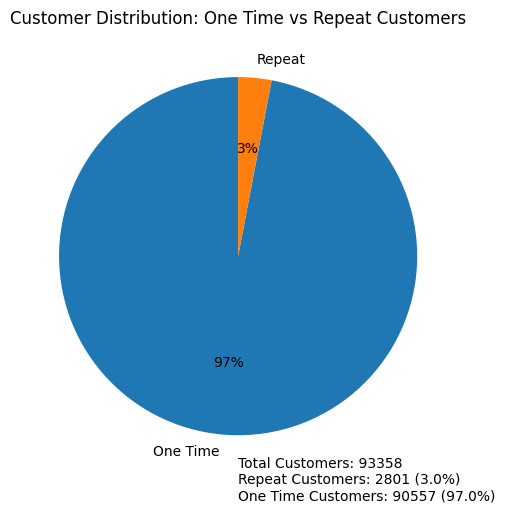

In [35]:
plt.figure(figsize=(5,5))

plt.pie(
    [one_time_cust, repeat_cust],
    labels=["One Time", "Repeat"],
    autopct="%1.0f%%",
    startangle=90)

plt.title("Customer Distribution: One Time vs Repeat Customers")
plt.figtext(
     0.5, -0.01,
    f"Total Customers: {total_customers}\nRepeat Customers: {repeat_cust} ({repeat_percent}%)\nOne Time Customers: {one_time_cust} ({one_time_percent}%)",
    ha="left",
    fontsize=10
)
plt.tight_layout()
plt.show()

**Insight:** Only 3% of customers made more than one purchase, while 97% placed only one order. This indicates that repeat customers make up a very small portion of the customer base.

The results may suggest that the company focuses primarily on attracting new customers rather than encouraging repeat purchases from existing ones.


**Recommendation:** Analyze which product categories have the highest repeat purchase rates to identify products that naturally contribute to customer retention.

If increasing customer retention is one of business goals, assess the potential impact of loyalty programs, personalized marketing campaigns and targeted promotions.

## How often do customers place multiple orders?

The analysis below uses the data on the number of customer orders calculated in the previous section

In [36]:
orders_distribution = customers["total_orders"].value_counts().sort_index().reset_index()
orders_distribution

,total_orders,count
0,1,90557
1,2,2573
2,3,181
3,4,28
4,5,9
5,6,5
6,7,3
7,9,1
8,15,1


In [37]:
distribution = orders_distribution.copy()

distribution["total_orders"] = distribution["total_orders"].apply(
    lambda x: "5+" if x >= 5 else str(x))

distribution = distribution.groupby("total_orders")["count"].sum().reset_index()
distribution


,total_orders,count
0,1,90557
1,2,2573
2,3,181
3,4,28
4,5+,19


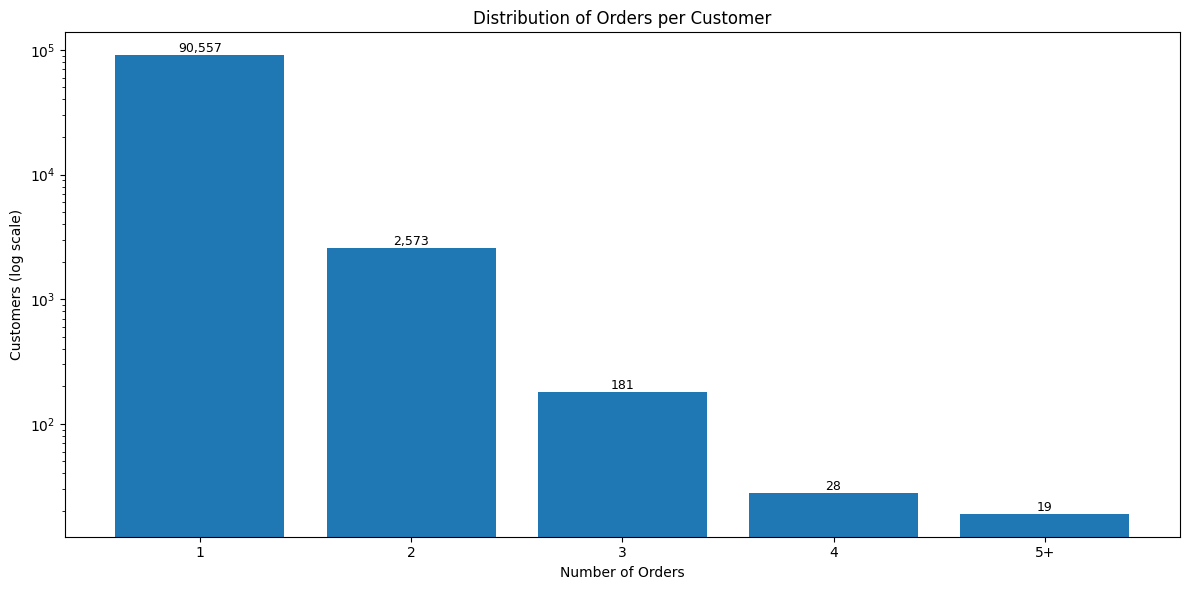

In [38]:
plt.figure(figsize=(12, 6))

plt.bar(distribution["total_orders"], distribution["count"])

plt.title("Distribution of Orders per Customer")
plt.xlabel("Number of Orders")
plt.ylabel("Customers (log scale)")

for i, value in enumerate(distribution["count"]):
    plt.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=9)

plt.yscale("log")

plt.tight_layout()
plt.show()

**Insight:** Most customers placed only one order, and the number of customers drops sharply as the number of repeat orders increases.

Among regular customers, the most common behavior is placing two orders, while only a very small number of customers make three or more purchases.

Customers who have placed five or more orders are extremely rare, indicating that long-term purchasing activity is uncommon.

**Recommendation:** Evaluate opportunities to encourage repeat purchases through personalized promotions, loyalty programs or post-purchase customer engagement.

Examine whether purchase frequency varies by product category, customer segment or region to identify areas with higher customer retention potential.

Analyze customers who make repeat purchases to identify behavioral patterns or product categories associated with higher customer retention rates.

## What is the average order value?

In [39]:
query = """
select o.order_id, sum(oi.price) as order_value
from `Olist.olist_orders_dataset` o
join `Olist.olist_order_items_dataset` oi
on o.order_id = oi.order_id
where o.order_status = 'delivered'
group by o.order_id
"""
orders = client.query(query).to_dataframe()
orders.head()

,order_id,order_value
0,bfbd0f9bdef84302105ad712db648a6c,134.97
1,be5bc2f0da14d8071e2d45451ad119d9,21.90
2,c4b41c36dd589e901f6879f25a74ec1d,9.90
3,a8c3f65a43b2e956cbfca10db4300853,179.90
4,79ffdd52a918bbe867895a4b183d6457,299.99


In [40]:
orders["order_value"].describe()

,order_value
count,96478.000000
mean,137.041586
std,209.045198
min,0.850000
25%,45.900000
50%,86.575000
75%,149.900000
max,13440.000000


In [41]:
mean = orders['order_value'].mean()
median = orders['order_value'].median()

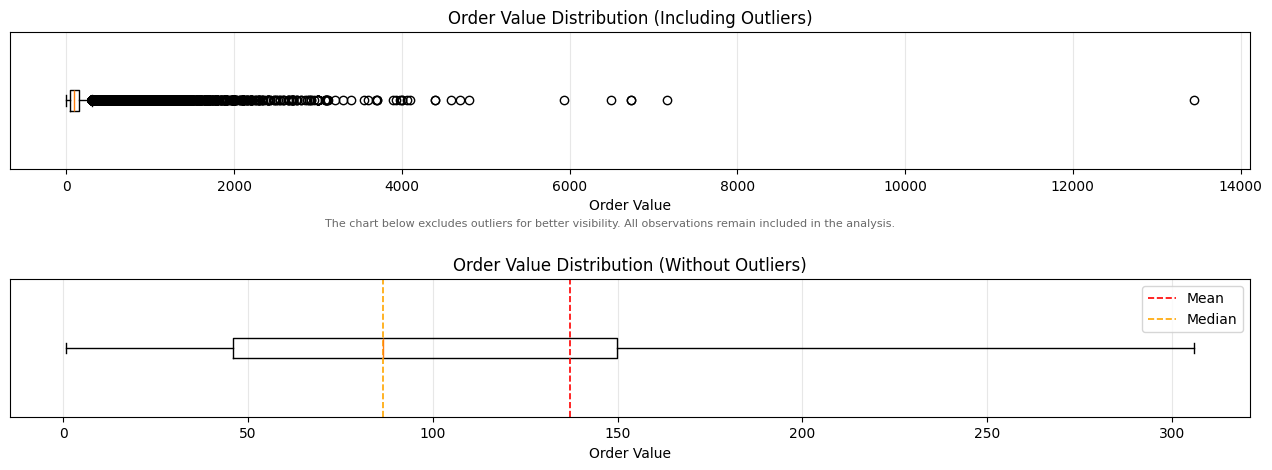

In [42]:
fig, ax = plt.subplots(2, 1, figsize=(16, 5))

ax[0].boxplot(orders["order_value"],vert=False)
ax[0].set_title("Order Value Distribution (Including Outliers)")
ax[0].set_xlabel("Order Value")
ax[0].grid(axis='x', alpha=0.3)

ax[0].set_yticks([])

ax[1].boxplot(orders["order_value"],vert=False, showfliers=False)
ax[1].set_title("Order Value Distribution (Without Outliers)")
ax[1].set_xlabel("Order Value")
ax[1].grid(axis='x', alpha=0.3)

ax[1].axvline(mean, color='red', linestyle='--', linewidth=1.2, label='Mean')
ax[1].axvline(median, color='orange', linestyle='--', linewidth=1.2, label='Median')
ax[1].legend()

ax[1].set_yticks([])

fig.text(
    0.5,
    0.49,
    "The chart below excludes outliers for better visibility. All observations remain included in the analysis.",
    ha="center",
    fontsize=8,
    color="dimgray"
)
plt.subplots_adjust(hspace=0.8)


plt.show()


In [43]:
print(f"Average Order Value: {orders['order_value'].mean():.2f}")
print(f"Median Order Value: {orders['order_value'].median():.2f}")
print(f"Minimum: {orders['order_value'].min():.2f}")
print(f"Maximum: {orders['order_value'].max():.2f}")
print(f"25th Percentile: {orders["order_value"].quantile(0.25)}")
print(f"75th Percentile: {orders["order_value"].quantile(0.75)}")

Average Order Value: 137.04
Median Order Value: 86.57
Minimum: 0.85
Maximum: 13440.00
25th Percentile: 45.9
75th Percentile: 149.9


**Insight:** The average order value of 137.04 significantly exceeds the median of 86.57, indicating that high-value orders are driving up the overall average.

Half of all completed orders fall within the range of 45.9 to 149.9, indicating that most customer purchases are low- or moderately-priced.

At the same time, a relatively small number of high-cost purchases result in numerous significant emissions.

**Recommendation:** When evaluating sales performance, use not only the average order value but also the median, since the median better reflects a typical customer purchase.

Track changes in the distribution of order values over time to identify shifts in customer buying behavior.

Continue to track high-value orders separately, as they have a significant impact on the average order value.

## Do payment methods and installments influence order value?

### Multiple payment methods check

In [44]:
query = """
select
    count(*) as multi_payment_orders
from (
    select order_id
    from `Olist.olist_order_payments_dataset`
    group by order_id
    having count(payment_type) > 1)
"""

multi_payment = client.query(query).to_dataframe()
multi_payment

,multi_payment_orders
0,2961


Approximately 2% of orders were paid using multiple payment methods (most commonly voucher + credit card). Since a single order cannot be uniquely assigned to one payment category, these orders will be excluded from the analysis.

### Inconsistent installment records check

In [45]:
query = """
select
    count(*) as inconsistent_orders
from (
    select order_id
    from `Olist.olist_order_payments_dataset`
    group by order_id
    having
       count(distinct payment_type)=1 and count(distinct payment_installments)>1)
"""

inconsistent_orders = client.query(query).to_dataframe()
inconsistent_orders

,inconsistent_orders
0,148


An additional 148 orders contained inconsistent installment values despite having only one payment method. Since the correct installment count cannot be determined, these orders will be also excluded.

### Final SQL

In [46]:
query = """
with order_values as (
select order_id, sum(price) as order_value
from `Olist.olist_order_items_dataset`
group by order_id
),

valid_orders as (
select order_id
from `Olist.olist_order_payments_dataset`
group by order_id
having count(distinct payment_type)=1 and count(distinct payment_installments)=1
),

payment_info as (
select order_id, max(payment_type) as payment_type, max(payment_installments) as payment_installments
from `Olist.olist_order_payments_dataset`
group by order_id
)

select ov.order_id, ov.order_value, p.payment_type, p.payment_installments
from valid_orders v
join order_values ov
on v.order_id=ov.order_id
join payment_info p
on v.order_id=p.order_id
join `Olist.olist_orders_dataset` o
on v.order_id=o.order_id
where o.order_status='delivered'
"""
payments = client.query(query).to_dataframe()
payments

,order_id,order_value,payment_type,payment_installments
0,744bade1fcf9ff3f31d860ace076d422,45.90,credit_card,0
1,1a57108394169c0b47d8f876acc9ba2d,83.38,credit_card,0
2,45ed6e85398a87c253db47c2d9f48216,56.99,voucher,1
3,fb4de3600d359f84927517e78ff9ba54,69.90,voucher,1
4,874904b7cdcd377a298d82e303930223,59.90,voucher,1
...,...,...,...,...
94146,ff36cbc44b8f228e0449c92ef089c843,699.00,credit_card,24
94147,63dbe0c8e63e5f1b4deec09d4f044a7f,750.00,credit_card,24
94148,d74fca7ee2ce7587c45eefb0fea95ed8,1050.00,credit_card,24
94149,fcbb6af360b31b05460c2c8e524588c0,1050.00,credit_card,24


In [47]:
payment_summary = (
    payments.groupby("payment_type").agg(
        orders=("order_id", "count"),
        avg_order_value=("order_value", "mean"),
        median_order_value=("order_value", "median")
    ).round(2).sort_values("avg_order_value", ascending=False).reset_index())
payment_summary

,payment_type,orders,avg_order_value,median_order_value
0,credit_card,71978,142.60,89.90
1,boleto,19191,121.40,74.90
2,debit_card,1484,119.86,70.45
3,voucher,1498,85.91,53.99


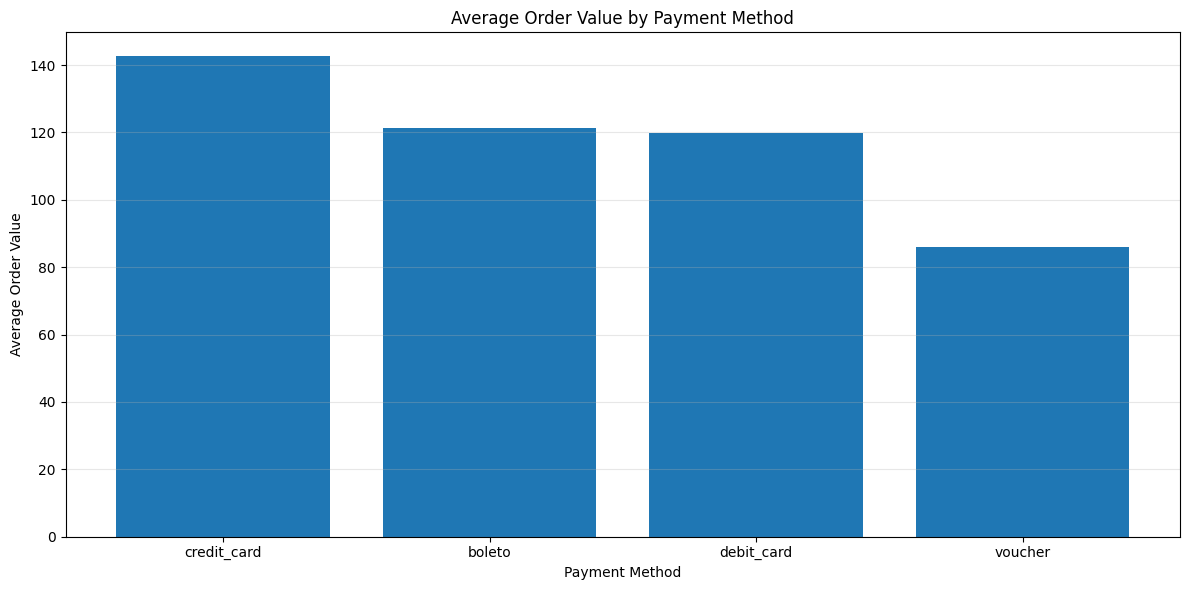

In [48]:
plt.figure(figsize=(12, 6))

plt.bar(payment_summary["payment_type"], payment_summary["avg_order_value"])

plt.title("Average Order Value by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Average Order Value")


plt.grid(axis="y", alpha=0.3)


plt.tight_layout()
plt.show()

In [49]:
installments_summary = payments.groupby("payment_installments").agg(
    orders=("order_id", "count"),
    avg_order_value=("order_value", "mean"),
    median_order_value=("order_value", "median")
).round(2).sort_values("payment_installments").reset_index()
installments_summary


,payment_installments,orders,avg_order_value,median_order_value
0,0,2,64.64,64.64
1,1,45334,100.19,59.98
2,2,11792,107.37,89.99
3,3,9967,120.84,90.00
4,4,6761,140.97,99.00
5,5,4996,157.82,106.90
6,6,3726,182.12,119.90
7,7,1537,161.60,110.00
8,8,4075,279.12,189.00
9,9,608,172.28,89.90


In [50]:
installments_summary = installments_summary[installments_summary["payment_installments"] <= 10]

Installment plans above 10 payments will be excluded from the visualization due to the very small number of orders, which makes their averages statistically unstable.

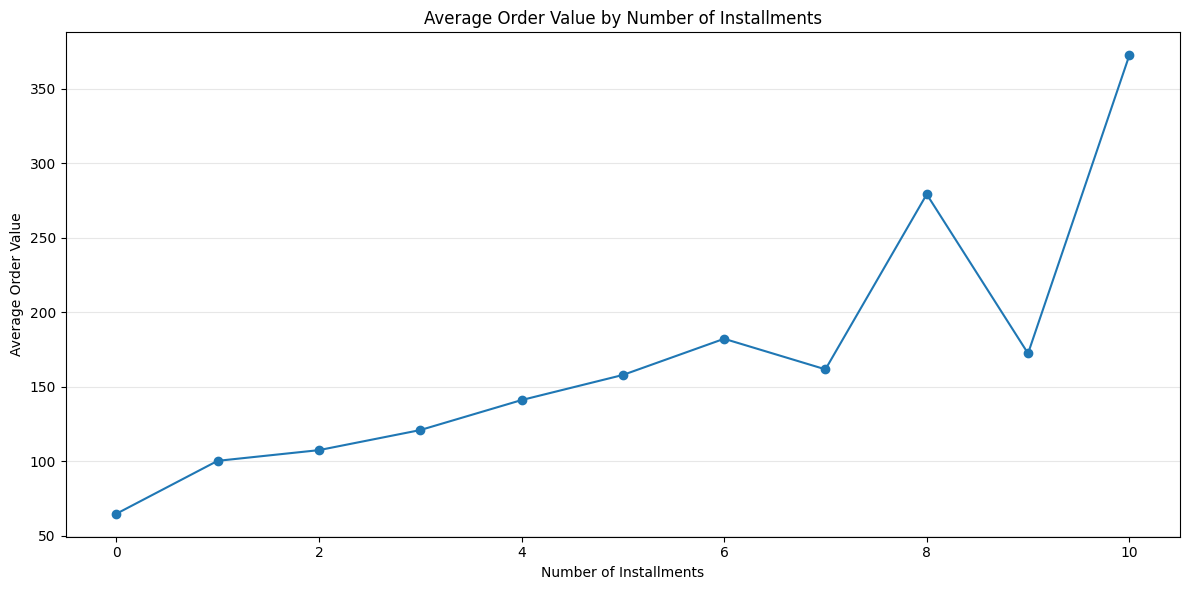

In [51]:
plt.figure(figsize=(12, 6))

plt.plot(installments_summary['payment_installments'], installments_summary['avg_order_value'], marker='o')

plt.title("Average Order Value by Number of Installments")
plt.xlabel("Number of Installments")
plt.ylabel("Average Order Value")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Insight:** Credit card payments have the highest average order value (≈142), while payments made with vouchers have the lowest (≈85). The average order value for payments made via Boleto and debit cards is roughly the same (≈120).

The average order value generally increases as the number of installment payments rises from 0 to 10. Customers who use installment plans typically place orders for higher amounts than those who pay in full.

**Recommendation:** Track customers who use installment plans, as they make larger purchases and may represent an important customer segment.

Conduct a more detailed analysis of the relationship between installment plan terms and buyer behavior, taking into account additional factors such as product category or customer location, to better understand what contributes to higher order values.

## Which states have the highest average revenue per customer?

### Check if there are any customers who are associated with multiple states at the same time

In [52]:
query = """
select count (*) as customers_with_multiple_states
from (
    select customer_unique_id
    from `Olist.olist_customers_dataset`
    group by customer_unique_id
    having count(distinct customer_state) > 1
)
"""
customers_with_multiple_states = client.query(query).to_dataframe()
customers_with_multiple_states

,customers_with_multiple_states
0,39


**Notes:** Since the purpose of the analysis is to calculate the average revenue per customer by state, customers associated with multiple states will be excluded from the analysis to avoid counting the same customer toward multiple regions.

In [53]:
query = """
with valid_customers as (
    select customer_unique_id
    from `Olist.olist_customers_dataset`
    group by customer_unique_id
    having count(distinct customer_state) = 1
)

select c.customer_unique_id as customer, sum(oi.price) as revenue, c.customer_state as state
from `Olist.olist_orders_dataset` o
join `Olist.olist_order_items_dataset` oi
on o.order_id = oi.order_id
join `Olist.olist_customers_dataset` c
on o.customer_id = c.customer_id
join valid_customers vc
on c.customer_unique_id = vc.customer_unique_id
where order_status = 'delivered'
group by c.customer_unique_id, c.customer_state
"""
customers_revenue = client.query(query).to_dataframe()
customers_revenue

,customer,revenue,state
0,958df1746c3131f9c7359ae5fb848497,161.55,SE
1,6e4c8eed6842146f77d917f7b437b4c2,148.00,RN
2,d748ffd406ceef24252c8879c1b27f96,65.90,SE
3,c6b482cd350f5dc9a48ec4c1292c72bd,18.90,RN
4,9342b18c97a2bbf3fa9d97aceb0b6dd4,399.80,RN
...,...,...,...
93314,c21046e84e00a13cf813c70ebf1acf25,78.00,SP
93315,fe5d307ceeb4ba712f7f926d3fe49304,115.98,SP
93316,9906fc374d7fd8d7a8574dd27b1c0c0a,149.00,SP
93317,c7b32f8451f68e4cd4130b53f73464a0,74.00,SP


In [54]:
state_summary = customers_revenue.groupby('state').agg(
    customers = ('customer', 'count'),
    avg_revenue = ('revenue', 'mean'),
    median_revenue = ('revenue', 'median')
).round(2).sort_values('avg_revenue', ascending = False).reset_index()
state_summary

,state,customers,avg_revenue,median_revenue
0,PB,502,223.78,115.95
1,AC,76,209.62,122.40
2,AL,387,203.76,106.90
3,AP,66,202.65,108.95
4,RO,230,198.27,118.44
5,PA,922,189.23,109.93
6,PI,464,182.59,113.80
7,TO,267,181.28,108.00
8,MT,854,178.04,99.99
9,RN,464,176.95,103.24


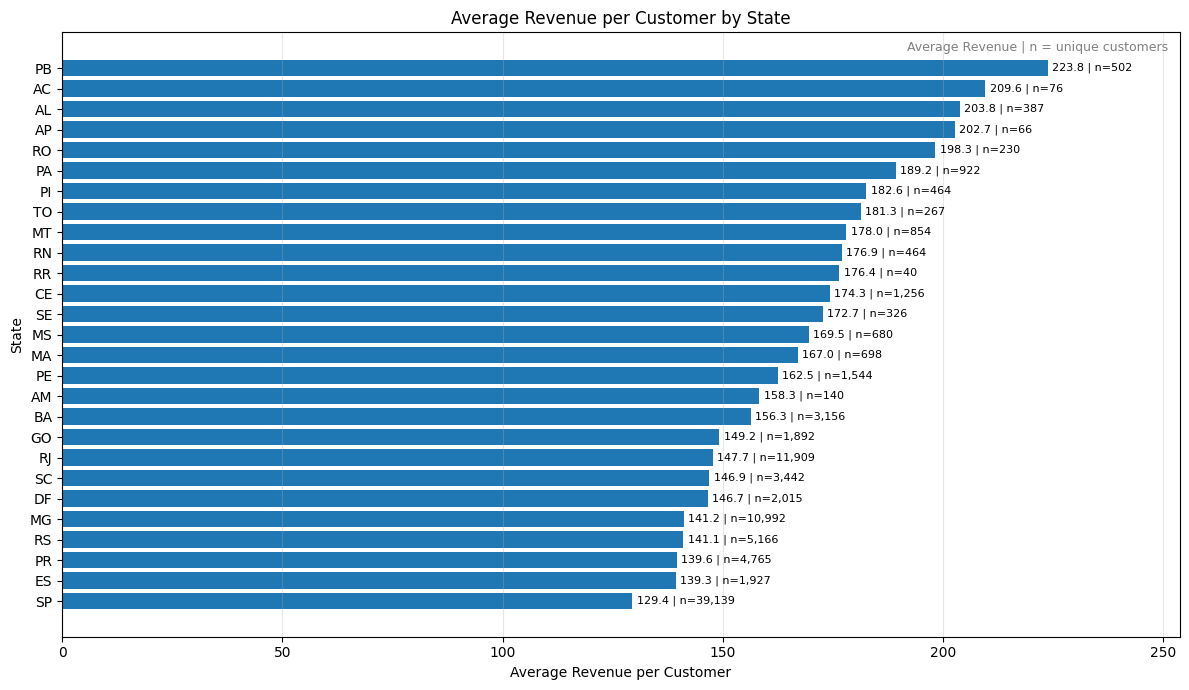

In [55]:
plt.figure(figsize=(12, 7))

plt.barh(state_summary["state"], state_summary["avg_revenue"])

plt.title("Average Revenue per Customer by State")
plt.xlabel("Average Revenue per Customer")
plt.ylabel("State")

for i, row in state_summary.iterrows():
    plt.text(
        row["avg_revenue"] + 1,
        i,
        f'{row["avg_revenue"]:.1f} | n={row["customers"]:,}',
        va='center',
        fontsize=8
    )

plt.figtext(
    0.76, 0.92,
    "Average Revenue | n = unique customers",
    ha="left",
    fontsize=9,
    color="gray"
)

plt.xlim(0, state_summary["avg_revenue"].max() + 30)
plt.grid(axis="x", alpha=0.3)
plt.gca().invert_yaxis()


plt.tight_layout()
plt.show()

**Insight:** Average revenue per customer varies significantly by state: from 129.4 in SP to 223.8 in PB.

Some states with the highest average revenue figures (PB, AC, AL, AP) have a relatively small customer base, so their average should be interpreted with caution.
SP undoubtedly has the largest customer base (39139 customers), but the lowest average revenue per customer.

States with a large number of customers, such as SP, MG, RJ, RS and PR, generally generate lower average revenue per customer than many smaller states.

**Recommendation:** Focus customer retention and upselling efforts on large markets such as SP, MG, RJ, RS and PR, where even a small increase in average revenue per customer could have a substantial impact on total revenue.

Examine what sets states with high revenue per customer apart to determine whether similar purchasing models or best practices can be applied in other regions.


## How does average order value change with customer purchase frequency?

In [56]:
query = """
with order_values as (
  select order_id, sum(price) as order_value
  from `Olist.olist_order_items_dataset`
  group by order_id
)

select c.customer_unique_id as customer, count(DISTINCT o.order_id) as orders_value,
    sum(ov.order_value) as total_revenue, avg(ov.order_value) as avg_revenue
from `Olist.olist_orders_dataset` o
join order_values ov
on o.order_id = ov.order_id
join `Olist.olist_customers_dataset` c
on o.customer_id = c.customer_id
where order_status = 'delivered'
group by c.customer_unique_id
"""
customers_purchase = client.query(query).to_dataframe()
customers_purchase


,customer,orders_value,total_revenue,avg_revenue
0,830d5b7aaa3b6f1e9ad63703bec97d23,1,134.97,134.970000
1,32ea3bdedab835c3aa6cb68ce66565ef,3,104.89,34.963333
2,2f64e403852e6893ae37485d5fcacdaf,1,21.90,21.900000
3,4e23e1826902ec9f208e8cc61329b494,2,157.90,78.950000
4,3f4f614c632af7fc7508462a7cb55ac2,1,9.90,9.900000
...,...,...,...,...
93353,944446c90b2f4d7bbd2d605396c42670,1,149.90,149.900000
93354,ff176d08b6e19c92b5ccfcdfa01cdffa,1,149.90,149.900000
93355,aed42e87e8e87dcd62a19f37b59b1700,1,149.90,149.900000
93356,ee3719b7c352b9582aae9f515946f207,1,149.90,149.900000


In [57]:
purchase_short = customers_purchase.copy()

purchase_short["orders_value"] = purchase_short["orders_value"].apply(
    lambda x: "5+" if x >= 5 else str(x))

purchase_short

,customer,orders_value,total_revenue,avg_revenue
0,830d5b7aaa3b6f1e9ad63703bec97d23,1,134.97,134.970000
1,32ea3bdedab835c3aa6cb68ce66565ef,3,104.89,34.963333
2,2f64e403852e6893ae37485d5fcacdaf,1,21.90,21.900000
3,4e23e1826902ec9f208e8cc61329b494,2,157.90,78.950000
4,3f4f614c632af7fc7508462a7cb55ac2,1,9.90,9.900000
...,...,...,...,...
93353,944446c90b2f4d7bbd2d605396c42670,1,149.90,149.900000
93354,ff176d08b6e19c92b5ccfcdfa01cdffa,1,149.90,149.900000
93355,aed42e87e8e87dcd62a19f37b59b1700,1,149.90,149.900000
93356,ee3719b7c352b9582aae9f515946f207,1,149.90,149.900000


In [58]:
purchase_summary = purchase_short.groupby('orders_value').agg(
    customers = ('customer', 'count'),
    avg_total_revenue = ('total_revenue', 'mean'),
    avg_order_revenue = ('avg_revenue', 'mean')
).round(2).sort_index().reset_index()

purchase_summary

,orders_value,customers,avg_total_revenue,avg_order_revenue
0,1,90557,137.96,137.96
1,2,2573,245.35,122.67
2,3,181,364.50,121.50
3,4,28,676.67,169.17
4,5+,19,642.77,107.44


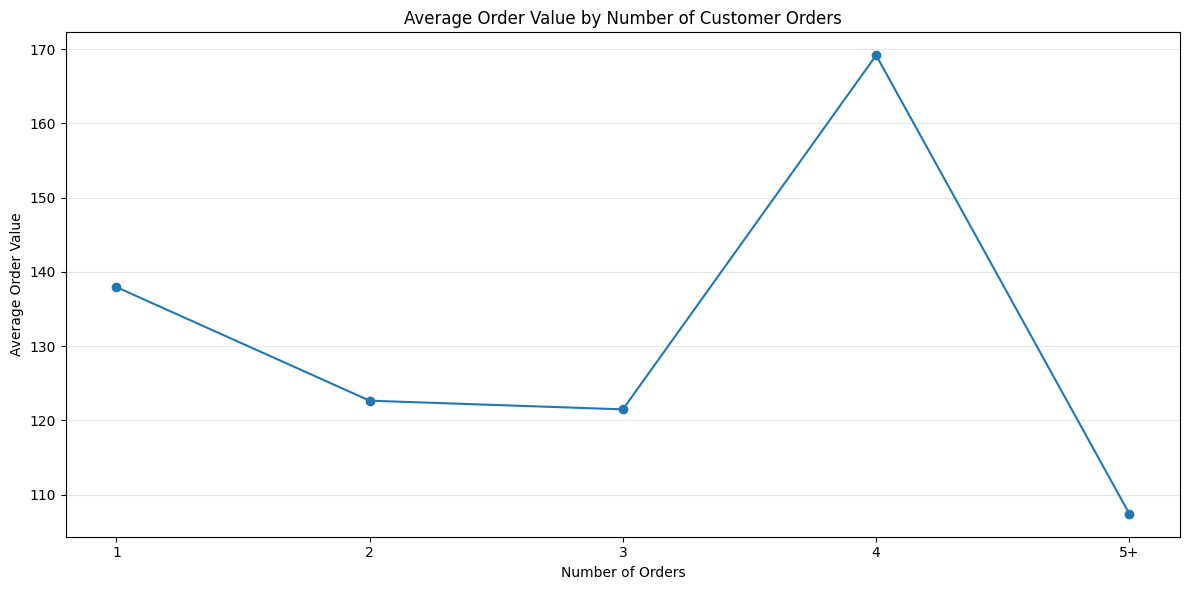

In [59]:
plt.figure(figsize=(12, 6))

plt.plot(purchase_summary["orders_value"], purchase_summary["avg_order_revenue"], marker="o")

plt.title("Average Order Value by Number of Customer Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Average Order Value")

plt.grid(axis="y", alpha=0.3)


plt.tight_layout()
plt.show()

**Insight:** The average order value does not always increase in proportion to the frequency of purchases. The apparent spike among customers who have placed 4 orders is based on a very small sample size (28), so it should be interpreted with caution.

Overall, repeat customers generate more revenue over the entire period of engagement primarily because they shop more frequently, not because they spend more per order.

**Recommendation:** Prioritize customer retention strategies that encourage repeat purchases. Analysis shows that long-term revenue growth is driven primarily by an increase in purchase frequency, rather than by an increase in the value of individual orders.